# Activity 1.2 : Training Neural Networks


#### Objective(s):

This activity aims to demonstrate how to train neural networks using keras

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to build and train neural networks
* Demonstrate how to evaluate and plot the model using training and validation loss


#### Resources:
* Jupyter Notebook

CI Pima Diabetes Dataset

* pima-indians-diabetes.csv


#### Procedures

Load the necessary libraries

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns

%matplotlib inline

In [79]:
## Import Keras objects for Deep Learning

from keras.models  import Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam, SGD, RMSprop

Load the dataset

In [80]:

filepath = "pima-indians-diabetes.csv"
names = ["times_pregnant", "glucose_tolerance_test", "blood_pressure", "skin_thickness", "insulin",
         "bmi", "pedigree_function", "age", "has_diabetes"]
diabetes_df = pd.read_csv(filepath, names=names)

Check the top 5 samples of the data

In [81]:

print(diabetes_df.shape)
diabetes_df.sample(5)

(768, 9)


,times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
369,1,133,102,28,140,32.8,0.234,45,1
625,4,90,88,47,54,37.7,0.362,29,0
638,7,97,76,32,91,40.9,0.871,32,1
325,1,157,72,21,168,25.6,0.123,24,0
735,4,95,60,32,0,35.4,0.284,28,0


In [82]:
diabetes_df.dtypes

,0
times_pregnant,int64
glucose_tolerance_test,int64
blood_pressure,int64
skin_thickness,int64
insulin,int64
bmi,float64
pedigree_function,float64
age,int64
has_diabetes,int64


In [83]:
X = diabetes_df.iloc[:, :-1].values
y = diabetes_df["has_diabetes"].values

Split the data to Train, and Test (75%, 25%)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11111)

In [85]:
np.mean(y), np.mean(1-y)

(np.float64(0.3489583333333333), np.float64(0.6510416666666666))

Build a single hidden layer neural network using 12 nodes.
Use the sequential model with single layer network and input shape to 8.



Normalize the data

In [86]:
normalizer = StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

Define the model:
* Input size is 8-dimensional
* 1 hidden layer, 12 hidden nodes, sigmoid activation
* Final layer with one node and sigmoid activation (standard for binary classification)

In [87]:


model  = Sequential([
    Dense(12, input_shape=(8,), activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


View the model summary

In [88]:

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_168 (Dense)               │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

Train the model
* Compile the model with optimizer, loss function and metrics
* Use the fit function to return the run history.


In [89]:
model.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=200)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4904 - loss: 0.7884 - val_accuracy: 0.5052 - val_loss: 0.7798
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5136 - loss: 0.7730 - val_accuracy: 0.5208 - val_loss: 0.7699
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5207 - loss: 0.7654 - val_accuracy: 0.5208 - val_loss: 0.7604
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5572 - loss: 0.7216 - val_accuracy: 0.5156 - val_loss: 0.7513
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5695 - loss: 0.7318 - val_accuracy: 0.5208 - val_loss: 0.7426
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5803 - loss: 0.7041 - val_accuracy: 0.5365 - val_loss: 0.7343
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5813 - loss: 0.7410 - val_accuracy: 0.5521 - val_loss: 0.7263
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5964 - loss: 0.6927 - val_accuracy: 0.5573 - 

In [90]:
## Like we did for the Random Forest, we generate two kinds of predictions
#  One is a hard decision, the other is a probabilitistic score.

y_pred_prob_nn_1 = model.predict(X_test_norm)
y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [91]:
# Let's check out the outputs to get a feel for how keras apis work.
y_pred_class_nn_1[:10]

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0]], dtype=int32)

In [92]:
y_pred_prob_nn_1[:10]

array([[0.48547342],
       [0.6096549 ],
       [0.24982606],
       [0.14145608],
       [0.16701055],
       [0.51592445],
       [0.08872356],
       [0.25941998],
       [0.9068146 ],
       [0.25001076]], dtype=float32)

Create the plot_roc function

In [93]:
def plot_roc(y_test, y_pred, model_name):
    fpr, tpr, thr = roc_curve(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(fpr, tpr, 'k-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)  # roc curve for random model
    ax.grid(True)
    ax.set(title='ROC Curve for {} on PIMA diabetes problem'.format(model_name),
           xlim=[-0.01, 1.01], ylim=[-0.01, 1.01])



Evaluate the model performance and plot the ROC CURVE

accuracy is 0.755
roc-auc is 0.821


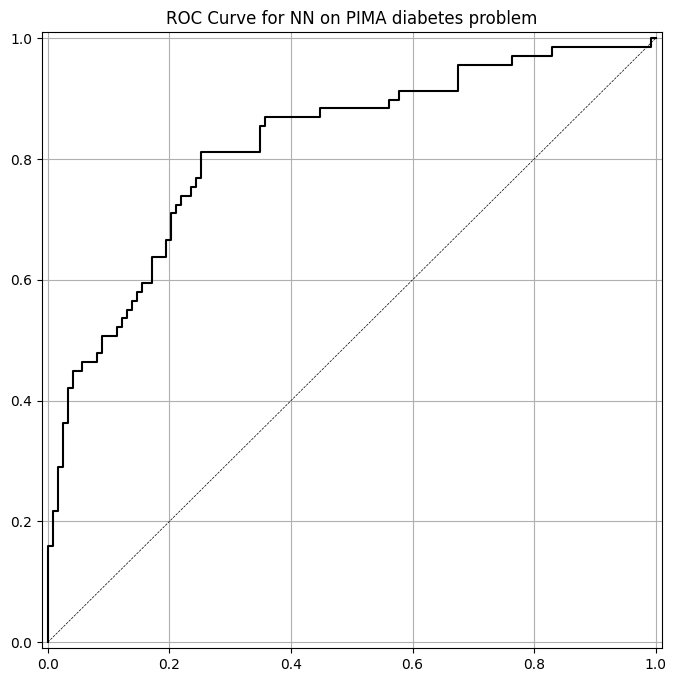

In [94]:

print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_1)))

plot_roc(y_test, y_pred_prob_nn_1, 'NN')

 Plot the training loss and the validation loss over the different epochs and see how it looks

In [95]:
run_hist_1.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

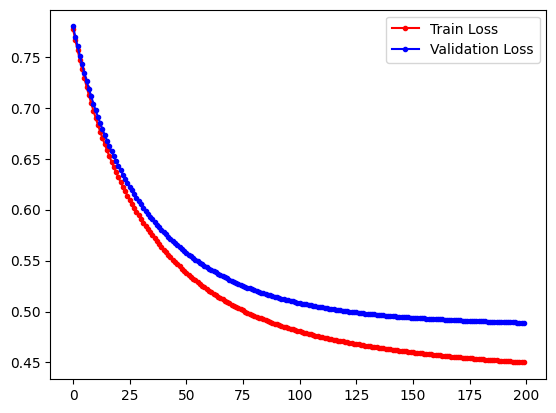

In [96]:
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

What is your interpretation about the result of the train and validation loss?

The graph show difference between the training loss of train and validation. The plot for both losses shows a big gap that indicates overfitting, wherein training has less loss but when validated shows more losses.

#type your answer here

#### Supplementary Activity

* Build a model with two hidden layers, each with 6 nodes
* Use the "relu" activation function for the hidden layers, and "sigmoid" for the final layer
* Use a learning rate of .003 and train for 1500 epochs
* Graph the trajectory of the loss functions, accuracy on both train and test set
* Plot the roc curve for the predictions
* Use different learning rates, numbers of epochs, and network structures.
* Plot the results of training and validation loss using different learning rates, number of epocgs and network structures
* Interpret your result

In [97]:
from keras.layers import Input

model_2_hidden = Sequential([
    Input(shape=(8,)),
    Dense(6, activation="relu"),
    Dense(6, activation="relu"),
    Dense(1, activation="sigmoid")
])
model_2_hidden.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
model_2_hidden.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_170 (Dense)               │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103 (412.00 B)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=1500)

Epoch 1/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7841 - loss: 0.4450 - val_accuracy: 0.7552 - val_loss: 0.4890
Epoch 2/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8090 - loss: 0.4484 - val_accuracy: 0.7552 - val_loss: 0.4889
Epoch 3/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7949 - loss: 0.4506 - val_accuracy: 0.7552 - val_loss: 0.4889
Epoch 4/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7877 - loss: 0.4785 - val_accuracy: 0.7552 - val_loss: 0.4888
Epoch 5/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8076 - loss: 0.4317 - val_accuracy: 0.7552 - val_loss: 0.4888
Epoch 6/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7914 - loss: 0.4606 - val_accuracy: 0.7552 - val_loss: 0.4887
Epoch 7/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8008 - loss: 0.4474 - val_accuracy: 0.7552 - val_loss: 0.4887
Epoch 8/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8136 - loss: 0.4340 - val_accuracy: 0

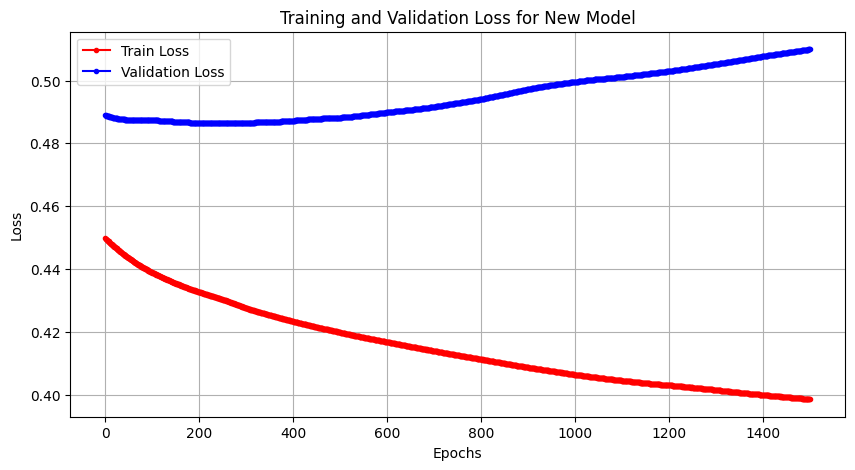

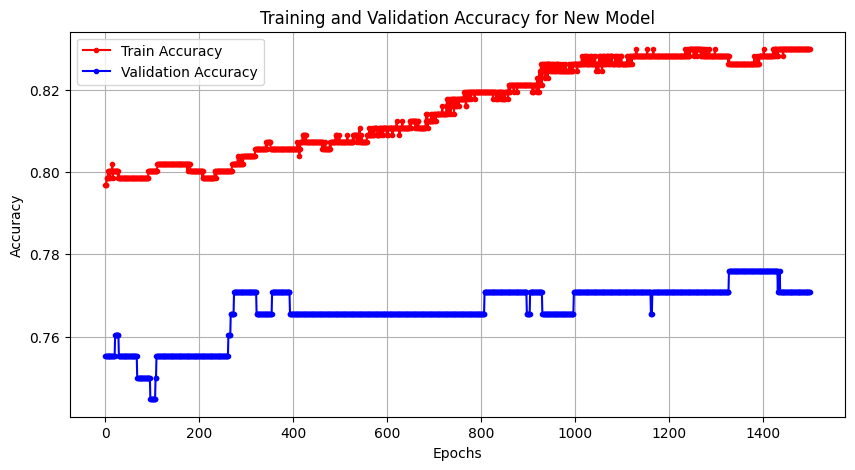

In [99]:
# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(run_hist_1.history["loss"], 'r', marker='.', label="Train Loss")
plt.plot(run_hist_1.history["val_loss"], 'b', marker='.', label="Validation Loss")
plt.title("Training and Validation Loss for New Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(run_hist_1.history["accuracy"], 'r', marker='.', label="Train Accuracy")
plt.plot(run_hist_1.history["val_accuracy"], 'b', marker='.', label="Validation Accuracy")
plt.title("Training and Validation Accuracy for New Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
y_pred_prob_nn_2 = model_2_hidden.predict(X_test_norm)
y_pred_class_nn_2 = (y_pred_prob_nn_1 > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [101]:
y_pred_class_nn_2[:10]

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0]], dtype=int32)

In [102]:
y_pred_prob_nn_2[:10]

array([[0.76931417],
       [0.9263706 ],
       [0.88124853],
       [0.6415457 ],
       [0.84605455],
       [0.7006613 ],
       [0.61569464],
       [0.8055552 ],
       [0.7713385 ],
       [0.7168351 ]], dtype=float32)

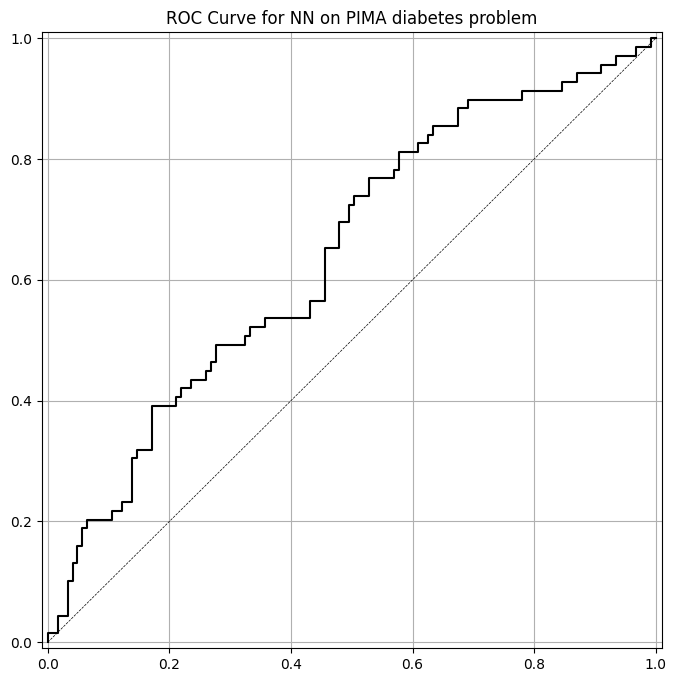

In [103]:
plot_roc(y_test, y_pred_prob_nn_2, 'NN')

In [104]:
from keras.layers import Input

model_2_hidden = Sequential([
    Input(shape=(8,)),
    Dense(64, activation="tanh"),
    Dense(64, activation="tanh"),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="softmax"),
    Dense(16, activation="softmax"),
    Dense(10, activation="tanh"),
    Dense(10, activation="tanh"),
    Dense(5, activation="relu"),
    Dense(5, activation="relu"),
    Dense(3, activation="softmax"),
    Dense(3, activation="softmax"),
    Dense(64, activation="tanh"),
    Dense(64, activation="tanh"),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="softmax"),
    Dense(16, activation="softmax"),
    Dense(10, activation="tanh"),
    Dense(10, activation="tanh"),
    Dense(5, activation="relu"),
    Dense(5, activation="relu"),
    Dense(3, activation="softmax"),
    Dense(3, activation="softmax"),
    Dense(1, activation="sigmoid")
])
model_2_hidden.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
model_2_hidden.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_173 (Dense)               │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_180 (Dense)               │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_185 (Dense)               │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_186 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_187 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_192 (Dense)               │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_193 (Dense)               │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_194 (Dense)               │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_195 (Dense)               │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_196 (Dense)               │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_197 (Dense)               │ (None, 1)              │             

 Total params: 17,818 (69.60 KB)

 Trainable params: 17,818 (69.60 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
model.compile(SGD(learning_rate = .05), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=500)

Epoch 1/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8345 - loss: 0.4039 - val_accuracy: 0.7708 - val_loss: 0.5184
Epoch 2/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8445 - loss: 0.3734 - val_accuracy: 0.7708 - val_loss: 0.5178
Epoch 3/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8408 - loss: 0.4056 - val_accuracy: 0.7656 - val_loss: 0.5179
Epoch 4/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8171 - loss: 0.4261 - val_accuracy: 0.7708 - val_loss: 0.5182
Epoch 5/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8329 - loss: 0.3949 - val_accuracy: 0.7708 - val_loss: 0.5182
Epoch 6/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8422 - loss: 0.3807 - val_accuracy: 0.7708 - val_loss: 0.5191
Epoch 7/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8500 - loss: 0.3943 - val_accuracy: 0.7708 - val_loss: 0.5184
Epoch 8/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8388 - loss: 0.3923 - val_accuracy: 0.7708 - 

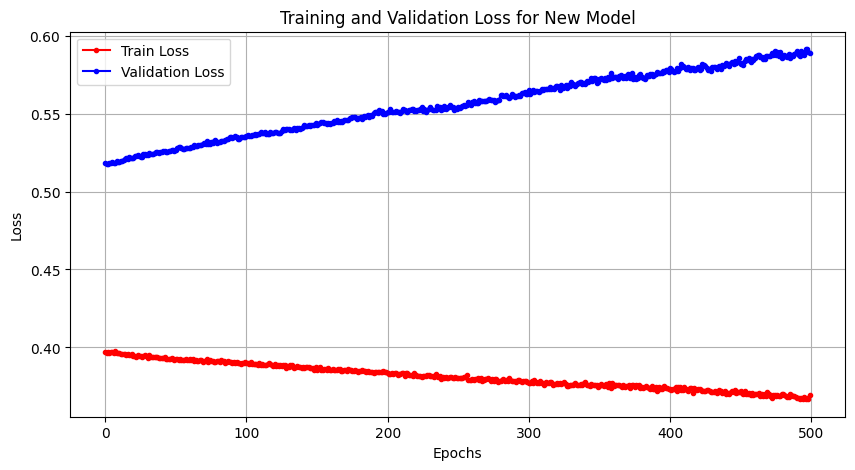

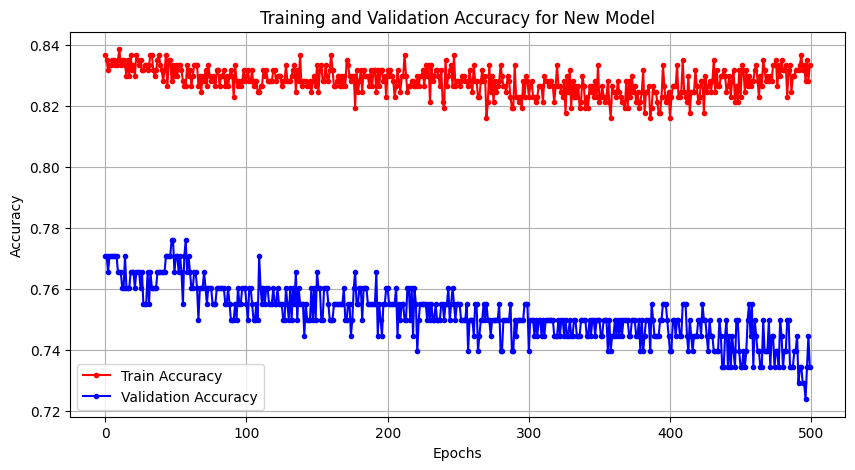

In [112]:
# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(run_hist_1.history["loss"], 'r', marker='.', label="Train Loss")
plt.plot(run_hist_1.history["val_loss"], 'b', marker='.', label="Validation Loss")
plt.title("Training and Validation Loss for New Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(run_hist_1.history["accuracy"], 'r', marker='.', label="Train Accuracy")
plt.plot(run_hist_1.history["val_accuracy"], 'b', marker='.', label="Validation Accuracy")
plt.title("Training and Validation Accuracy for New Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [107]:
y_pred_prob_nn_2 = model_2_hidden.predict(X_test_norm)
y_pred_class_nn_2 = (y_pred_prob_nn_1 > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


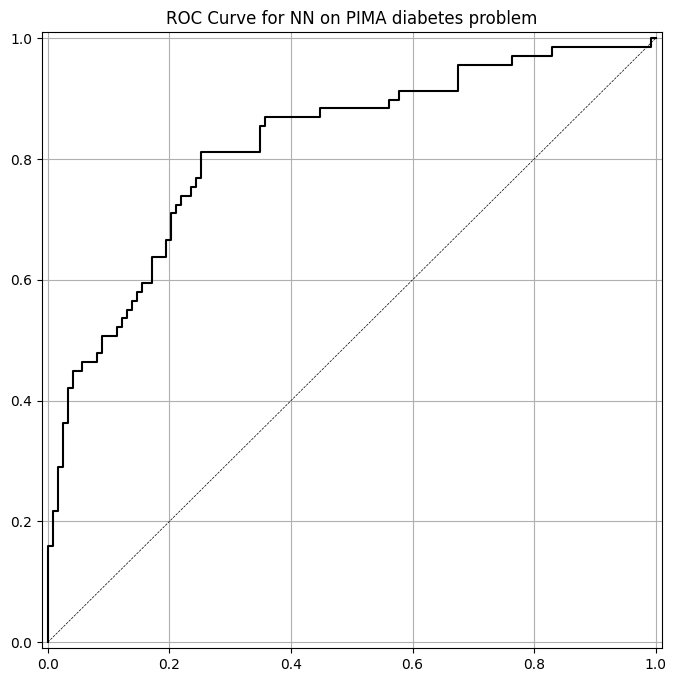

In [108]:
plot_roc(y_test, y_pred_prob_nn_1, 'NN')

#### Conclusion

In conclusionn, this activity thought me the algorithm and flow of neural networks. For me it is hard to make the model "just right" and always ended up overfitting with high accuracy training and lower when in validation. I've also tried changing activation function, increase hidden layers, and change learning rate(increasing and decreasing it).